# **Load and inspect data**

In [1]:
import pandas as pd

# read CSV
df = pd.read_csv("Covid_italy.csv")

# check shape
print("Shape:", df.shape)

# check columns
print("Columns:")
print(df.columns.tolist())

# preview head
print("\nFirst 5 rows:")
print(df.head())

# convert date
df["Date"] = pd.to_datetime(df["Date"])

# confirm conversion
print("\nData types after date conversion:")
print(df.dtypes)

Shape: (116, 20)
Columns:
['Date', 'Abruzzo', 'Basilicata', 'Calabria', 'Campania', 'Emilia-Romagna', 'Friuli Venezia Giulia', 'Lazio', 'Liguria', 'Lombardia', 'Marche', 'Molise', 'Piemonte', 'Puglia', 'Sardegna', 'Sicilia', 'Toscana', 'Umbria', "Valle d'Aosta", 'Veneto']

First 5 rows:
                  Date  Abruzzo  Basilicata  Calabria  Campania  \
0  2020-02-24T18:00:00        0           0         0         0   
1  2020-02-25T18:00:00        0           0         0         0   
2  2020-02-26T18:00:00        0           0         0         0   
3  2020-02-27T18:00:00        1           0         0         3   
4  2020-02-28T18:00:00        1           0         1         4   

   Emilia-Romagna  Friuli Venezia Giulia  Lazio  Liguria  Lombardia  Marche  \
0              18                      0      2        0        166       0   
1              26                      0      2        1        231       0   
2              46                      0      0       11        249     

# **Reshape and clean**

Melt (wide → long)

In [2]:
df_long = df.melt(id_vars="Date", var_name="Region", value_name="Cases")

print(df_long.head())
print("Shape after melt:", df_long.shape)

                 Date   Region  Cases
0 2020-02-24 18:00:00  Abruzzo      0
1 2020-02-25 18:00:00  Abruzzo      0
2 2020-02-26 18:00:00  Abruzzo      0
3 2020-02-27 18:00:00  Abruzzo      1
4 2020-02-28 18:00:00  Abruzzo      1
Shape after melt: (2204, 3)


Sort by Region and Date

In [3]:
df_long = df_long.sort_values(by=["Region", "Date"])

Compute DailyCases

In [4]:
df_long["DailyCases"] = df_long.groupby("Region")["Cases"].diff()

Handle missing values

In [5]:
df_long["DailyCases"] = df_long["DailyCases"].fillna(0)

Clip negative values

In [6]:
df_long["DailyCases"] = df_long["DailyCases"].clip(lower=0)

In [7]:
print(df_long.head(10))
print(df_long.describe())

                 Date   Region  Cases  DailyCases
0 2020-02-24 18:00:00  Abruzzo      0         0.0
1 2020-02-25 18:00:00  Abruzzo      0         0.0
2 2020-02-26 18:00:00  Abruzzo      0         0.0
3 2020-02-27 18:00:00  Abruzzo      1         1.0
4 2020-02-28 18:00:00  Abruzzo      1         0.0
5 2020-02-29 17:00:00  Abruzzo      2         1.0
6 2020-03-01 17:00:00  Abruzzo      5         3.0
7 2020-03-02 18:00:00  Abruzzo      5         0.0
8 2020-03-03 18:00:00  Abruzzo      6         1.0
9 2020-03-04 17:00:00  Abruzzo      7         1.0
                                Date         Cases   DailyCases
count                           2204   2204.000000  2204.000000
mean   2020-04-22 05:05:41.379310592   3005.211887    53.191924
min              2020-02-24 18:00:00      0.000000     0.000000
25%              2020-03-24 11:00:00    161.750000     0.000000
50%              2020-04-22 05:00:00    841.500000     0.000000
75%              2020-05-20 23:00:00   2920.250000    33.000000
ma

The dataset was reshaped from wide format to long format using the melt function, resulting in a structure with Date, Region, and Cases. The data was then sorted by Region and Date to ensure proper chronological order. Daily new cases were computed using the difference between consecutive cumulative values for each region. Missing values resulting from this operation were replaced with zero, and negative values caused by data corrections were clipped to zero to maintain consistency.

# **Feature engineering**

7-Day Moving Average (MA7)

In [8]:
#df_long["MA7"] = (
 #   df_long.groupby("Region")["DailyCases"]
  #  .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
#)


In [9]:
import numpy as np
# 7-day moving average based on current/past values

df_long["MA7_lag1"] = (
    df_long.groupby("Region")["DailyCases"]
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)

# lag features
df_long["Lag1"] = df_long.groupby("Region")["DailyCases"].shift(1)
df_long["Lag2"] = df_long.groupby("Region")["DailyCases"].shift(2)
df_long["Lag3"] = df_long.groupby("Region")["DailyCases"].shift(3)
df_long["Lag7"] = df_long.groupby("Region")["DailyCases"].shift(7)

# time features
df_long["DayOfWeek"] = df_long["Date"].dt.dayofweek
df_long["Month"] = df_long["Date"].dt.month
df_long["Week"] = df_long["Date"].dt.isocalendar().week.astype(int)

# growth rate
df_long["GrowthRate"] = df_long.groupby("Region")["DailyCases"].pct_change()
df_long["GrowthRate"] = df_long["GrowthRate"].replace([np.inf, -np.inf], np.nan)

# shift leakage-prone features so they use only information available up to previous day
#df_long["MA7_lag1"] = df_long.groupby("Region")["MA7"].shift(1)
df_long["GrowthRate_lag1"] = df_long.groupby("Region")["GrowthRate"].shift(1)

In [10]:
df_long = df_long.dropna(subset=["Lag1", "Lag7", "MA7_lag1", "GrowthRate_lag1"])
df_long["GrowthRate_lag1"] = df_long["GrowthRate_lag1"].clip(-5, 5)

In [11]:
print(df_long.head(10))
print(df_long.describe())

                  Date   Region  Cases  DailyCases  MA7_lag1  Lag1  Lag2  \
7  2020-03-02 18:00:00  Abruzzo      5         0.0  0.714286   3.0   1.0   
8  2020-03-03 18:00:00  Abruzzo      6         1.0  0.714286   0.0   3.0   
10 2020-03-05 17:00:00  Abruzzo      8         1.0  1.000000   1.0   1.0   
11 2020-03-06 17:00:00  Abruzzo      9         1.0  1.000000   1.0   1.0   
12 2020-03-07 18:00:00  Abruzzo     11         2.0  1.142857   1.0   1.0   
13 2020-03-08 18:00:00  Abruzzo     17         6.0  1.285714   2.0   1.0   
14 2020-03-09 18:00:00  Abruzzo     30        13.0  1.714286   6.0   2.0   
15 2020-03-10 18:00:00  Abruzzo     37         7.0  3.571429  13.0   6.0   
16 2020-03-11 17:00:00  Abruzzo     37         0.0  4.428571   7.0  13.0   
17 2020-03-12 17:00:00  Abruzzo     78        41.0  4.285714   0.0   7.0   

    Lag3  Lag7  DayOfWeek  Month  Week  GrowthRate  GrowthRate_lag1  
7    0.0   0.0          0      3    10   -1.000000         2.000000  
8    1.0   0.0         

# **EDA**

**Top Regions (Cumulative Cases)**

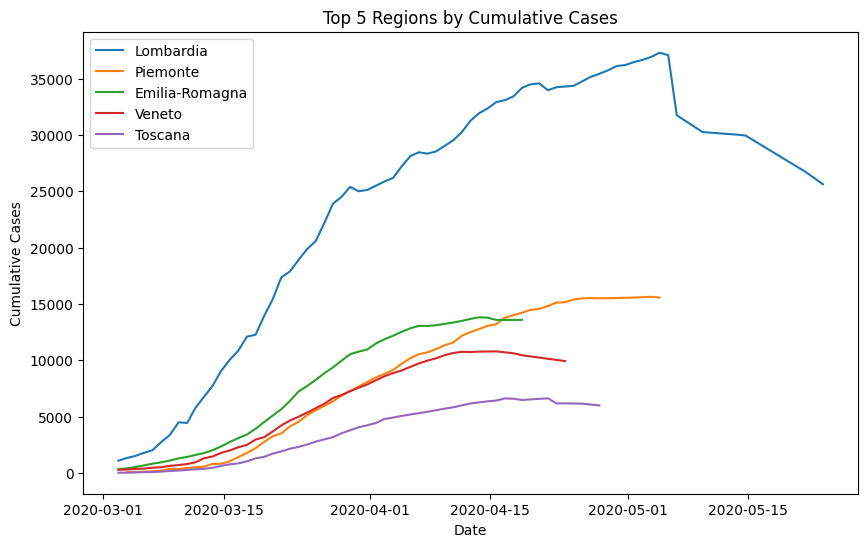

In [12]:
import matplotlib.pyplot as plt

# get top 5 regions by total cases
top_regions = (
    df_long.groupby("Region")["Cases"]
    .max()
    .sort_values(ascending=False)
    .head(5)
    .index
)

# filter data
df_top = df_long[df_long["Region"].isin(top_regions)]

# plot
plt.figure(figsize=(10,6))
for region in top_regions:
    subset = df_top[df_top["Region"] == region]
    plt.plot(subset["Date"], subset["Cases"], label=region)

plt.title("Top 5 Regions by Cumulative Cases")
plt.xlabel("Date")
plt.ylabel("Cumulative Cases")
plt.legend()
plt.show()

Lombardia showed the highest cumulative number of cases, followed by other major regions, indicating it as the primary hotspot during the outbreak.

**MA7 Trends (Smoothed Daily Cases)**

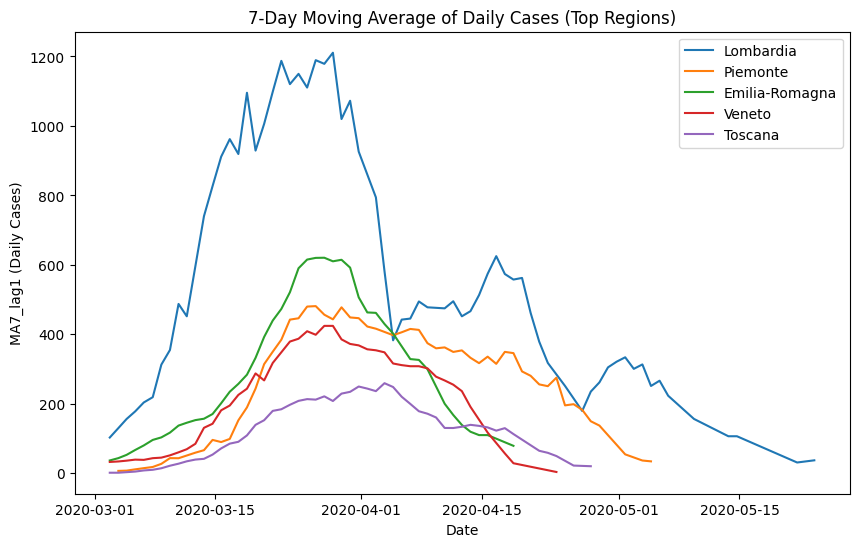

In [13]:
plt.figure(figsize=(10,6))
for region in top_regions:
    subset = df_top[df_top["Region"] == region]
    plt.plot(subset["Date"], subset["MA7_lag1"], label=region)

plt.title("7-Day Moving Average of Daily Cases (Top Regions)")
plt.xlabel("Date")
plt.ylabel("MA7_lag1 (Daily Cases)")
plt.legend()
plt.show()

The 7-day moving average highlights the peak of infections in late March and shows a gradual decline afterward.

**Italy Total Daily Cases**

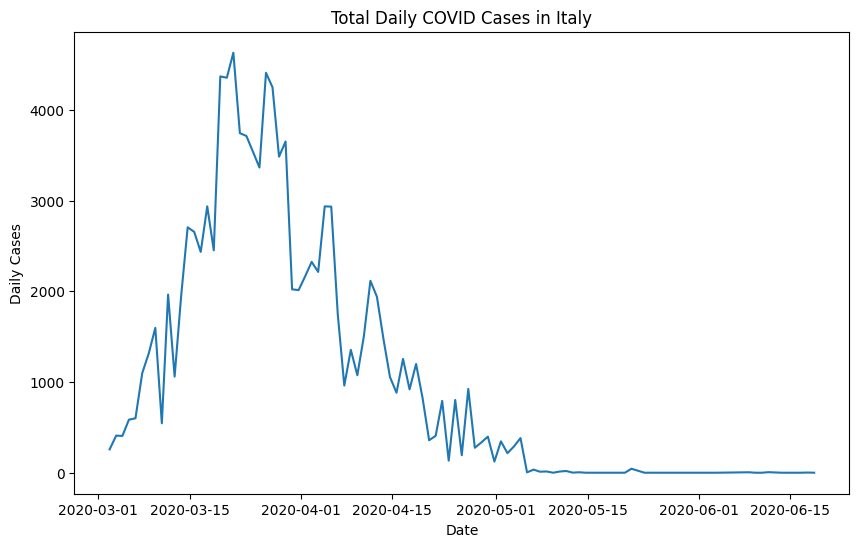

In [14]:
italy_daily = df_long.groupby("Date")["DailyCases"].sum()

plt.figure(figsize=(10,6))
plt.plot(italy_daily.index, italy_daily.values)

plt.title("Total Daily COVID Cases in Italy")
plt.xlabel("Date")
plt.ylabel("Daily Cases")
plt.show()

The total daily cases curve shows a sharp increase during early outbreak stages followed by stabilization, reflecting the impact of containment measures.

**Correlation Heatmap**

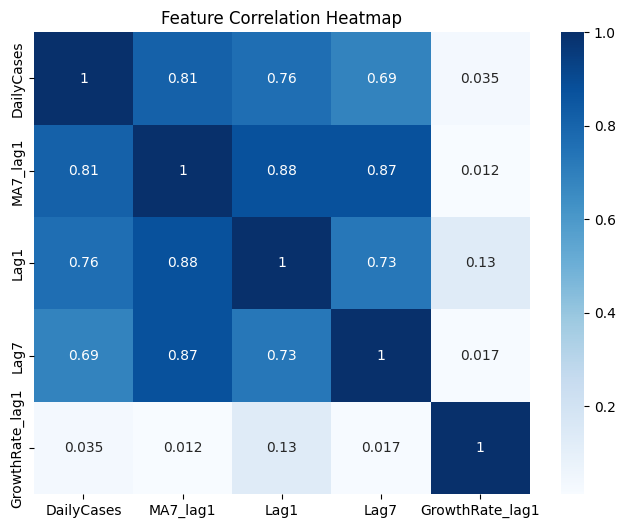

In [15]:
import seaborn as sns

features_corr = ["DailyCases", "MA7_lag1", "Lag1", "Lag7", "GrowthRate_lag1"]
corr = df_long[features_corr].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="Blues")
plt.title("Feature Correlation Heatmap")
plt.show()

Strong correlations were observed between DailyCases and lag features, indicating temporal dependency in the data.

**Lombardia Outbreak**

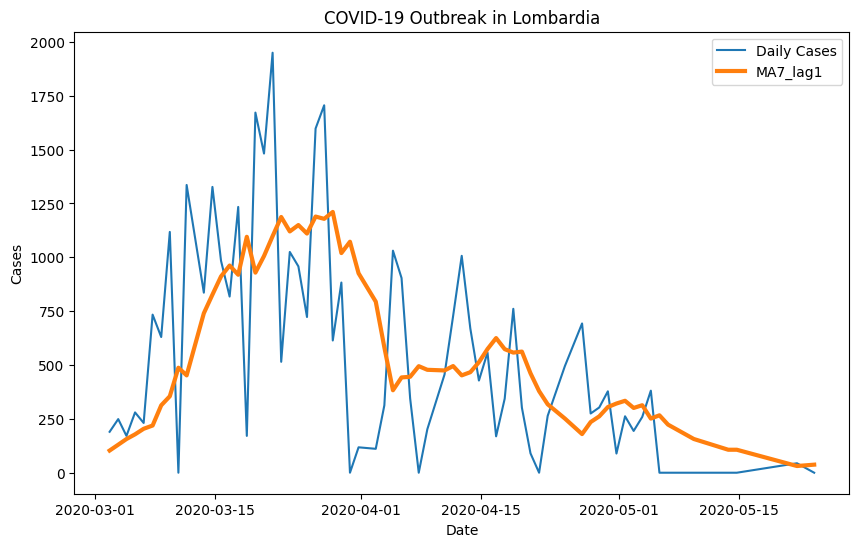

In [16]:
lombardia = df_long[df_long["Region"] == "Lombardia"]

plt.figure(figsize=(10,6))
plt.plot(lombardia["Date"], lombardia["DailyCases"], label="Daily Cases")
plt.plot(lombardia["Date"], lombardia["MA7_lag1"], label="MA7_lag1", linewidth=3)

plt.title("COVID-19 Outbreak in Lombardia")
plt.xlabel("Date")
plt.ylabel("Cases")
plt.legend()
plt.show()

Lombardia experienced the most severe outbreak, with a clear peak followed by a gradual decline, making it a key region for analysis.

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# **Modeling dataset**

In [18]:
df_model = df_long[df_long["Region"] == "Lombardia"].copy()

df_model = df_model[[
    "Date",
    "DailyCases",
    "Lag1",
    "Lag2",
    "Lag3",
    "Lag7",
    "MA7_lag1",
    "GrowthRate_lag1",
    "DayOfWeek",
    "Month",
    "Week"
]].sort_values("Date")

In [19]:
df_model = df_model.dropna()

In [20]:
# time-based split using date
split_date = "2020-04-15"

train = df_model[df_model["Date"] < split_date]
test = df_model[df_model["Date"] >= split_date]

In [21]:
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

In [22]:
features = ["MA7_lag1", "Lag1", "Lag2", "Lag3", "Lag7", "DayOfWeek", "Month", "Week", "GrowthRate_lag1"]
X_train = train[features]
y_train = train["DailyCases"]

X_test = test[features]
y_test = test["DailyCases"].reset_index(drop=True)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (41, 9)
Test size: (25, 9)


Did a time-based split because future data should not influence past predictions and it  maintains real-world forecasting scenario.

# **Naive Model (Baseline)**

**Idea: tomorrow = today**

In [23]:
y_pred_naive = test["Lag1"].reset_index(drop=True)
mae_naive = mean_absolute_error(y_test, y_pred_naive)
rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))

print("Naive MAE:", mae_naive)
print("Naive RMSE:", rmse_naive)

Naive MAE: 205.84
Naive RMSE: 270.70530101939266


# **Random Forest**

In [24]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=3,
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("RF MAE:", mae_rf)
print("RF RMSE:", rmse_rf)

RF MAE: 259.17712602342107
RF RMSE: 314.6955719345905


# **Sarimax**

In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [26]:
train_series = train.set_index("Date")["DailyCases"]
test_series = test.set_index("Date")["DailyCases"]
sarima = SARIMAX(
    train_series,
    order=(1,0,1), seasonal_order=(1,0,1,7)
)

sarima_model = sarima.fit(disp=False)

y_pred_sarima = sarima_model.forecast(steps=len(test_series))
y_pred_sarima = pd.Series(y_pred_sarima).reset_index(drop=True)

test_series = test_series.reset_index(drop=True)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [27]:
mae_sarima = mean_absolute_error(test_series, y_pred_sarima)
rmse_sarima = np.sqrt(mean_squared_error(test_series, y_pred_sarima))

print("SARIMA MAE:", mae_sarima)
print("SARIMA RMSE:", rmse_sarima)

SARIMA MAE: 180.42248608778647
SARIMA RMSE: 212.12758025035174


A simpler SARIMA configuration without differencing produced better results, indicating that the DailyCases series already captures differenced behavior and does not require additional transformation.

Multiple SARIMA configurations were tested. Initially, a model with differencing components was used; however, it resulted in higher error. A simpler model without differencing performed better, indicating that the DailyCases series already captures necessary transformations.

In [28]:
results = pd.DataFrame({
    "Model": ["Naive", "Random Forest", "SARIMA"],
    "MAE": [mae_naive, mae_rf, mae_sarima],
    "RMSE": [rmse_naive, rmse_rf, rmse_sarima]
})

print(results)

           Model         MAE        RMSE
0          Naive  205.840000  270.705301
1  Random Forest  259.177126  314.695572
2         SARIMA  180.422486  212.127580


**Forecast Plots**

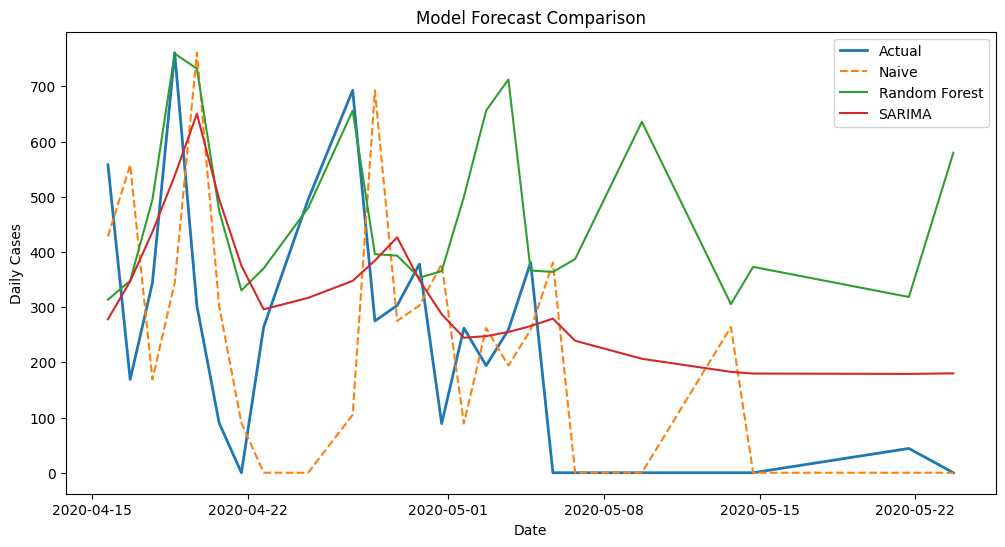

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(test["Date"], y_test, label="Actual", linewidth=2)
plt.plot(test["Date"], y_pred_naive, label="Naive", linestyle="--")
plt.plot(test["Date"], y_pred_rf, label="Random Forest")
plt.plot(test["Date"], y_pred_sarima, label="SARIMA")

plt.title("Model Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Daily Cases")
plt.legend()
plt.show()

**Feature Importance**

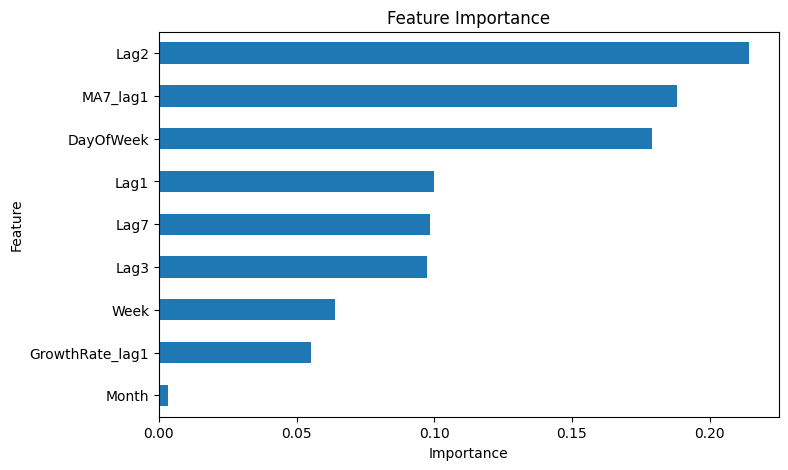

In [30]:
importance = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values()

plt.figure(figsize=(8,5))
importance.plot(kind="barh")
plt.title("Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The performance of the three models was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE). The results show clear differences in how each model captures the underlying patterns in the data.